In [1]:
!pip install tensorflow

In [2]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image

In [3]:
# ==============================
# 2️⃣ CONFIGURATION
# ==============================
BASE_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\FinalDataset\fd\fd\ColorJitter\Gaussian"   # Change this to your dataset
WORK_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\Resnet"  # Will store sampled images

IMG_SIZE = (128, 128)
BATCH_SIZE = 16
MAX_IMAGES_PER_CLASS = 200  # Limit per class for speed
EPOCHS = 15


In [4]:
# ==============================
# 3️⃣ FUNCTION: SAMPLE DATASET (No Delete)
# ==============================
def sample_dataset(src_dir, dest_dir, max_per_class):
    os.makedirs(dest_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        split_src = os.path.join(src_dir, split)
        split_dest = os.path.join(dest_dir, split)
        os.makedirs(split_dest, exist_ok=True)

        for cls in os.listdir(split_src):
            src_cls_dir = os.path.join(split_src, cls)
            dest_cls_dir = os.path.join(split_dest, cls)
            os.makedirs(dest_cls_dir, exist_ok=True)

            images = os.listdir(src_cls_dir)
            random.shuffle(images)
            sampled_imgs = images[:max_per_class]

            # Copy only if file doesn't already exist
            for img in sampled_imgs:
                src_path = os.path.join(src_cls_dir, img)
                dest_path = os.path.join(dest_cls_dir, img)
                if not os.path.exists(dest_path):
                    shutil.copy(src_path, dest_path)

# Create sampled dataset
sample_dataset(BASE_DIR, WORK_DIR, MAX_IMAGES_PER_CLASS)

In [5]:
# ==============================
# 4️⃣ DATA GENERATORS
# ==============================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2200 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.


In [6]:
# ==============================
# 5️⃣ RESNET MODEL (No Pretrained Weights)
# ==============================
base_model = ResNet50(weights=None, include_top=False,
                      input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# ==============================
# 6️⃣ TRAINING
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

c:\CODING\AI\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.1209 - loss: 2.9579 - val_accuracy: 0.0909 - val_loss: 2.4349
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.1259 - loss: 2.3520 - val_accuracy: 0.1303 - val_loss: 2.3685
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.1514 - loss: 2.2971 - val_accuracy: 0.1455 - val_loss: 2.4893
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.2009 - loss: 2.2576 - val_accuracy: 0.1750 - val_loss: 2.2513
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.2073 - loss: 2.2556 - val_accuracy: 0.1962 - val_loss: 2.2022
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.2186 - loss: 2.2230 - val_accuracy: 0.1727 - val_loss: 2.2809
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.2155 - loss: 2.2185 - val_accuracy: 0.2697 - val_loss: 2.1589
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.2255 - loss: 2.1889 - val_accu

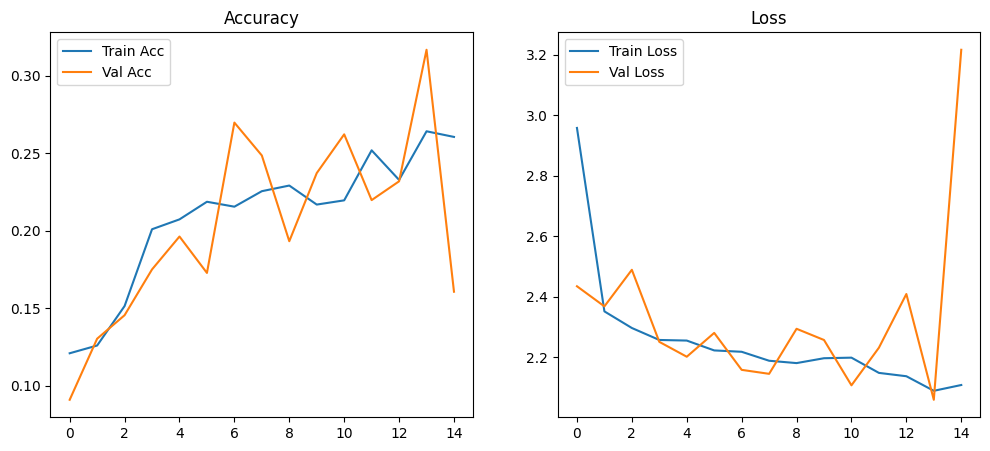

83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 432ms/step - accuracy: 0.2841 - loss: 2.1242
Test Accuracy: 0.2841
83/83 ━━━━━━━━━━━━━━━━━━━━ 33s 379ms/step
                       precision    recall  f1-score      support
Alopecia Areata         0.398496  0.441667  0.418972   120.000000
Contact Dermatitis      0.269231  0.175000  0.212121   120.000000
Folliculitis            0.153713  0.741667  0.254649   120.000000
Head Lice               0.333333  0.066667  0.111111   120.000000
Lichen Planus           0.000000  0.000000  0.000000   120.000000
Male Pattern Baldness   0.638655  0.633333  0.635983   120.000000
Psoriasis               0.000000  0.000000  0.000000   120.000000
Seborrheic Dermatitis   0.355556  0.133333  0.193939   120.000000
Telogen Effluvium       0.000000  0.000000  0.000000   120.000000
Tinea Capitis           0.196653  0.391667  0.261838   120.000000
healthy hair            0.663265  0.541667  0.596330   120.000000
accuracy                0.284091  0.284091  0.284091     0.284091
ma

c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


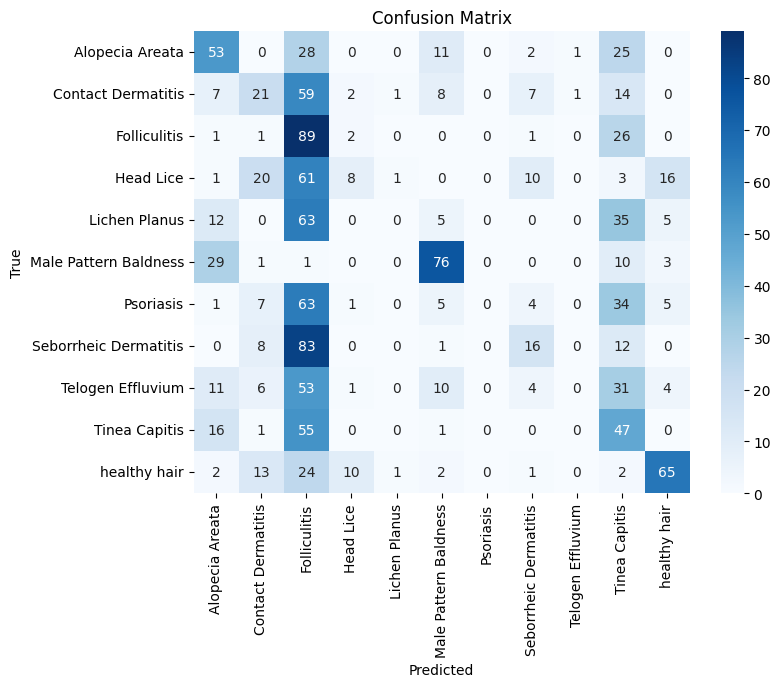

In [8]:
# ==============================
# 7️⃣ EVALUATION
# ==============================
# Accuracy & Loss Graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


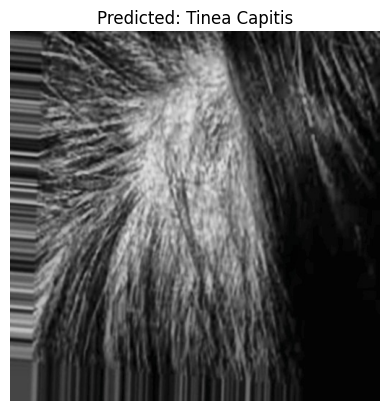

In [9]:
# ==============================
# 8️⃣ SAMPLE IMAGE PREDICTION
# ==============================
sample_img_path = test_gen.filepaths[0]
img = image.load_img(sample_img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
pred_class = class_labels[np.argmax(pred)]

plt.imshow(image.load_img(sample_img_path))
plt.title(f"Predicted: {pred_class}")
plt.axis("off")
plt.show()

In [10]:
# ==============================
# 9️⃣ SAVE MODEL
# ==============================
model.save("resnet_hair_disease_model.h5")